In [43]:
from hossam import load_data
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.spatial import ConvexHull

from kneed import KneeLocator
from sklearn.metrics import  silhouette_samples, silhouette_score
# Elbow Point 계산 라이브러리

from scipy.stats import normaltest

from matplotlib import cm                        

from matplotlib import cm
my_dpi = 200


In [42]:
import kneed
dir(kneed)


['DataGenerator',
 'KneeLocator',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_version',
 'data_generator',
 'find_shape',
 'knee_locator',
 'shape_detector']

In [2]:
my_dpi = 200 # 이미지 선명도(100~300)
fpath = "./NotoSansKR-Regular.ttf" # 한글을 지원하는 폰트 파일의 경로
fm.fontManager.addfont(fpath) # 폰트의 글꼴을 시스템에 등록함
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트 이름 추출
plt.rcParams['font.family'] = fname # 그래프에 한글 폰트 적용
plt.rcParams['font.size'] = 6 # 기본 폰트 크기
plt.rcParams['axes.unicode_minus'] = False # 그래프에 마이너스 깨짐 방지

In [3]:
origin = load_data("iris")
origin.head()

1936년 영국의 통계학자 로널드 피셔(Ronald A. Fisher)가 소개한 3가지 품종(setosa, versicolor, virginica)의 붓꽃(Iris)에 대한 꽃받침과 꽃잎의 길이와 너비 측정값으로 구성된 유명한 머신러닝 및 데이터 분석용 데이터셋.(출처: Kaggle)

field         description
------------  -------------
Sepal.Length  꽃밭침 길이
Sepal.Width   꽃밭침 너비
Petal.Length  꽃잎 길이
Petal.Width   꽃잎 너비
Species       품종



,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df = origin.drop("Species", axis=1)
df.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 📘#02.실루엣 스코어
📝[1]군집분석 수행<br>
📝[2]각 포인트에 대한 실루엣 계수 구하기<br>
📝[3]전체 실루엣 계수에 대한 평균 스코어<br>
📝[4]실루엣 스코어 시가고하 함수 정의<br>
📝[5]엘보우 포인트를 통해 도출한 k갑셍 대한 실루엣 스코어 시각화<br>
📝[6]k값의 변화에 따른 점수 시각화


In [13]:
best_k = 4

In [18]:
estimator= KMeans(n_clusters=best_k)
estimator.fit(df)
cluster = estimator.predict(df)
cluster

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 3, 1, 3, 1, 3, 1, 3, 3, 3, 3, 1, 3, 1,
       3, 3, 1, 3, 1, 3, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 1, 3, 1, 1, 3,
       3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 2, 1, 2, 1, 2, 2, 3, 2, 2, 2,
       1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 1, 2, 2, 2,
       1, 1, 1, 2, 2, 1, 1, 2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1], dtype=int32)

독립변수만으로 구성된 데이터프레임이 필요하다.

In [44]:
s_samples = silhouette_samples(X=df, labels=cluster)
s_samples

array([0.82983811, 0.78308343, 0.80107439, 0.77023104, 0.8260145 ,
       0.71142073, 0.79219252, 0.82949354, 0.7085028 , 0.79450277,
       0.77415413, 0.80746068, 0.77762018, 0.7061819 , 0.66838385,
       0.60531333, 0.74581637, 0.82739004, 0.66554987, 0.79339577,
       0.7475919 , 0.79884782, 0.76372127, 0.75569427, 0.73246417,
       0.76100725, 0.8042103 , 0.81672465, 0.81872101, 0.78485776,
       0.78105687, 0.76630148, 0.73141653, 0.68901157, 0.79819574,
       0.80557242, 0.76437216, 0.81754864, 0.72946133, 0.82551057,
       0.82602818, 0.57429012, 0.75154466, 0.76570033, 0.70471043,
       0.77593987, 0.78499716, 0.78821582, 0.79108004, 0.82757618,
       0.36930998, 0.33259562, 0.37965664, 0.55672231, 0.39203344,
       0.26490975, 0.42417741, 0.50114303, 0.35308837, 0.55611645,
       0.50398209, 0.24742993, 0.42701532, 0.28706896, 0.54627631,
       0.30508872, 0.17465733, 0.51814451, 0.02575921, 0.61079519,
       0.37162112, 0.35664328, 0.41023004, 0.15681863, 0.06789

In [46]:
s_score = silhouette_score(X=df, labels=cluster)
s_score

0.49535632852885064

In [48]:
def visualize_silhouette(estimator, X_features):

    # -------------------------------
    # Figure 생성
    # -------------------------------
    fig, (ax1, ax2) = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(18, 7)
    )

    # -------------------------------
    # Silhouette Score 계산
    # -------------------------------
    sil_avg = silhouette_score(
        X=X_features,
        labels=estimator.labels_
    )

    sil_values = silhouette_samples(
        X=X_features,
        labels=estimator.labels_
    )

    # -------------------------------
    # Silhouette Plot (좌측)
    # -------------------------------
    y_lower = 10

    plt.suptitle(
        "Number of Cluster : "
        + str(estimator.n_clusters)
        + ", Silhouette Score : "
        + str(round(sil_avg, 3))
    )

    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X_features) + (estimator.n_clusters + 1) * 10])
    ax1.set_yticks([])     # Clear y-axis labels / ticks
    ax1.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    ax1.grid(True)

    # -------------------------------
    # 클러스터별 Silhouette 영역
    # -------------------------------
    for i in range(estimator.n_clusters):

        ith_cluster_sil_values = sil_values[
            estimator.labels_ == i
        ]
        ith_cluster_sil_values.sort()

        size_cluster_i = ith_cluster_sil_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(
            float(i) / estimator.n_clusters
        )

        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_sil_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7
        )

        ax1.text(
            -0.05,
            y_lower + 0.5 * size_cluster_i,
            str(i)
        )

        y_lower = y_upper + 10

    # 평균 Silhouette 기준선
    ax1.axvline(
        x=sil_avg,
        color="red",
        linestyle="--"
    )

    # -------------------------------
    # 실제 클러스터 산점도 (우측)
    # -------------------------------
    colors = cm.nipy_spectral(
        estimator.labels_.astype(float) / estimator.n_clusters
    )

    ax2.scatter(
        X_features[X_features.columns[0]],
        X_features[X_features.columns[1]],
        marker="o",
        s=30,
        lw=0,
        alpha=0.7,
        c=colors,
        edgecolor="k"
    )

    # -------------------------------
    # 클러스터 중심점 표시
    # -------------------------------
    centers = estimator.cluster_centers_

    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k"
    )

    plt.tight_layout()
    plt.show()


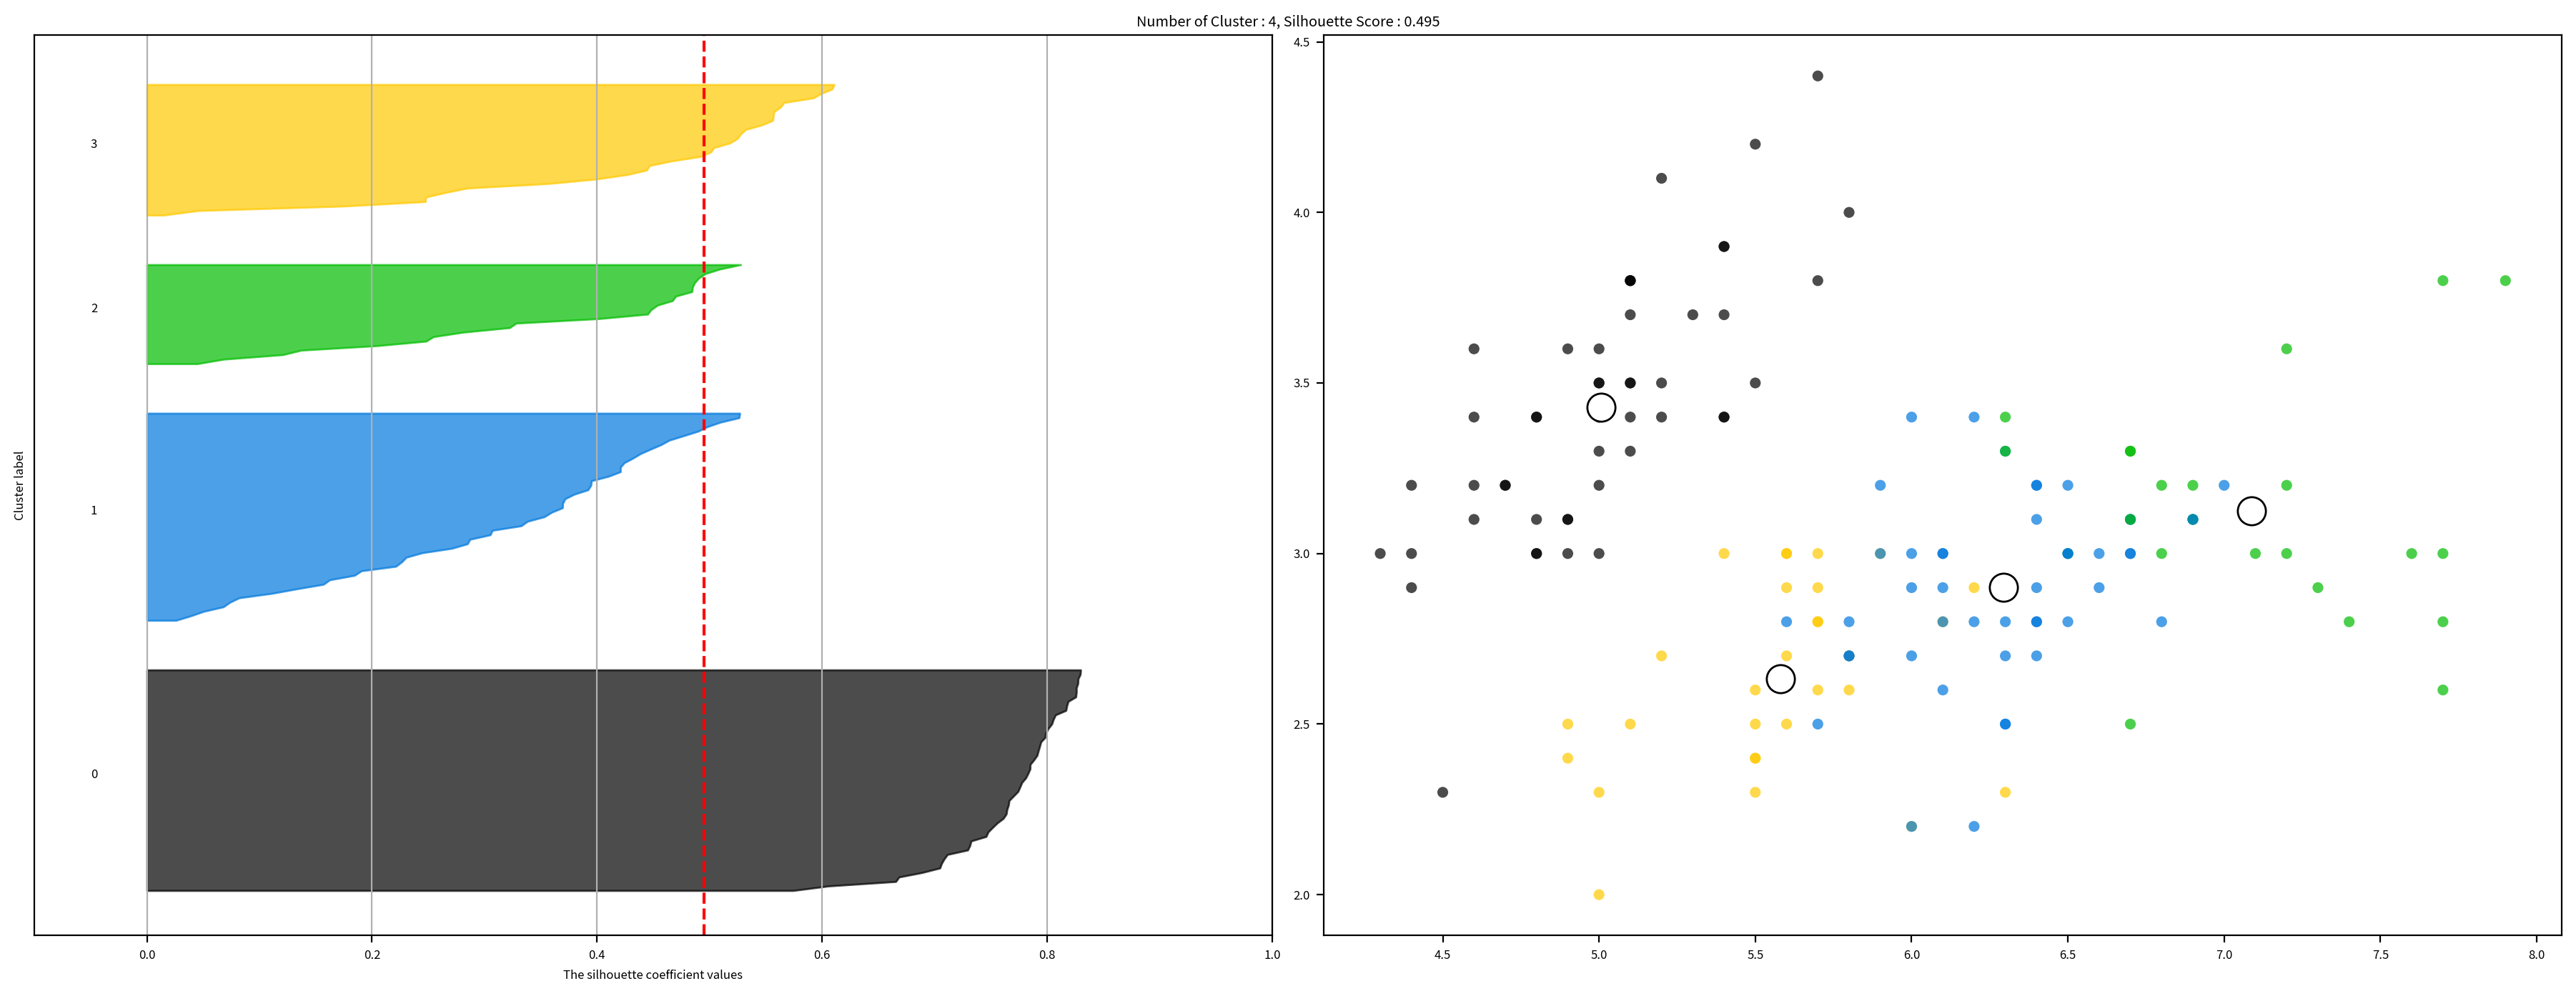

In [51]:
visualize_silhouette(estimator=estimator, X_features=df)

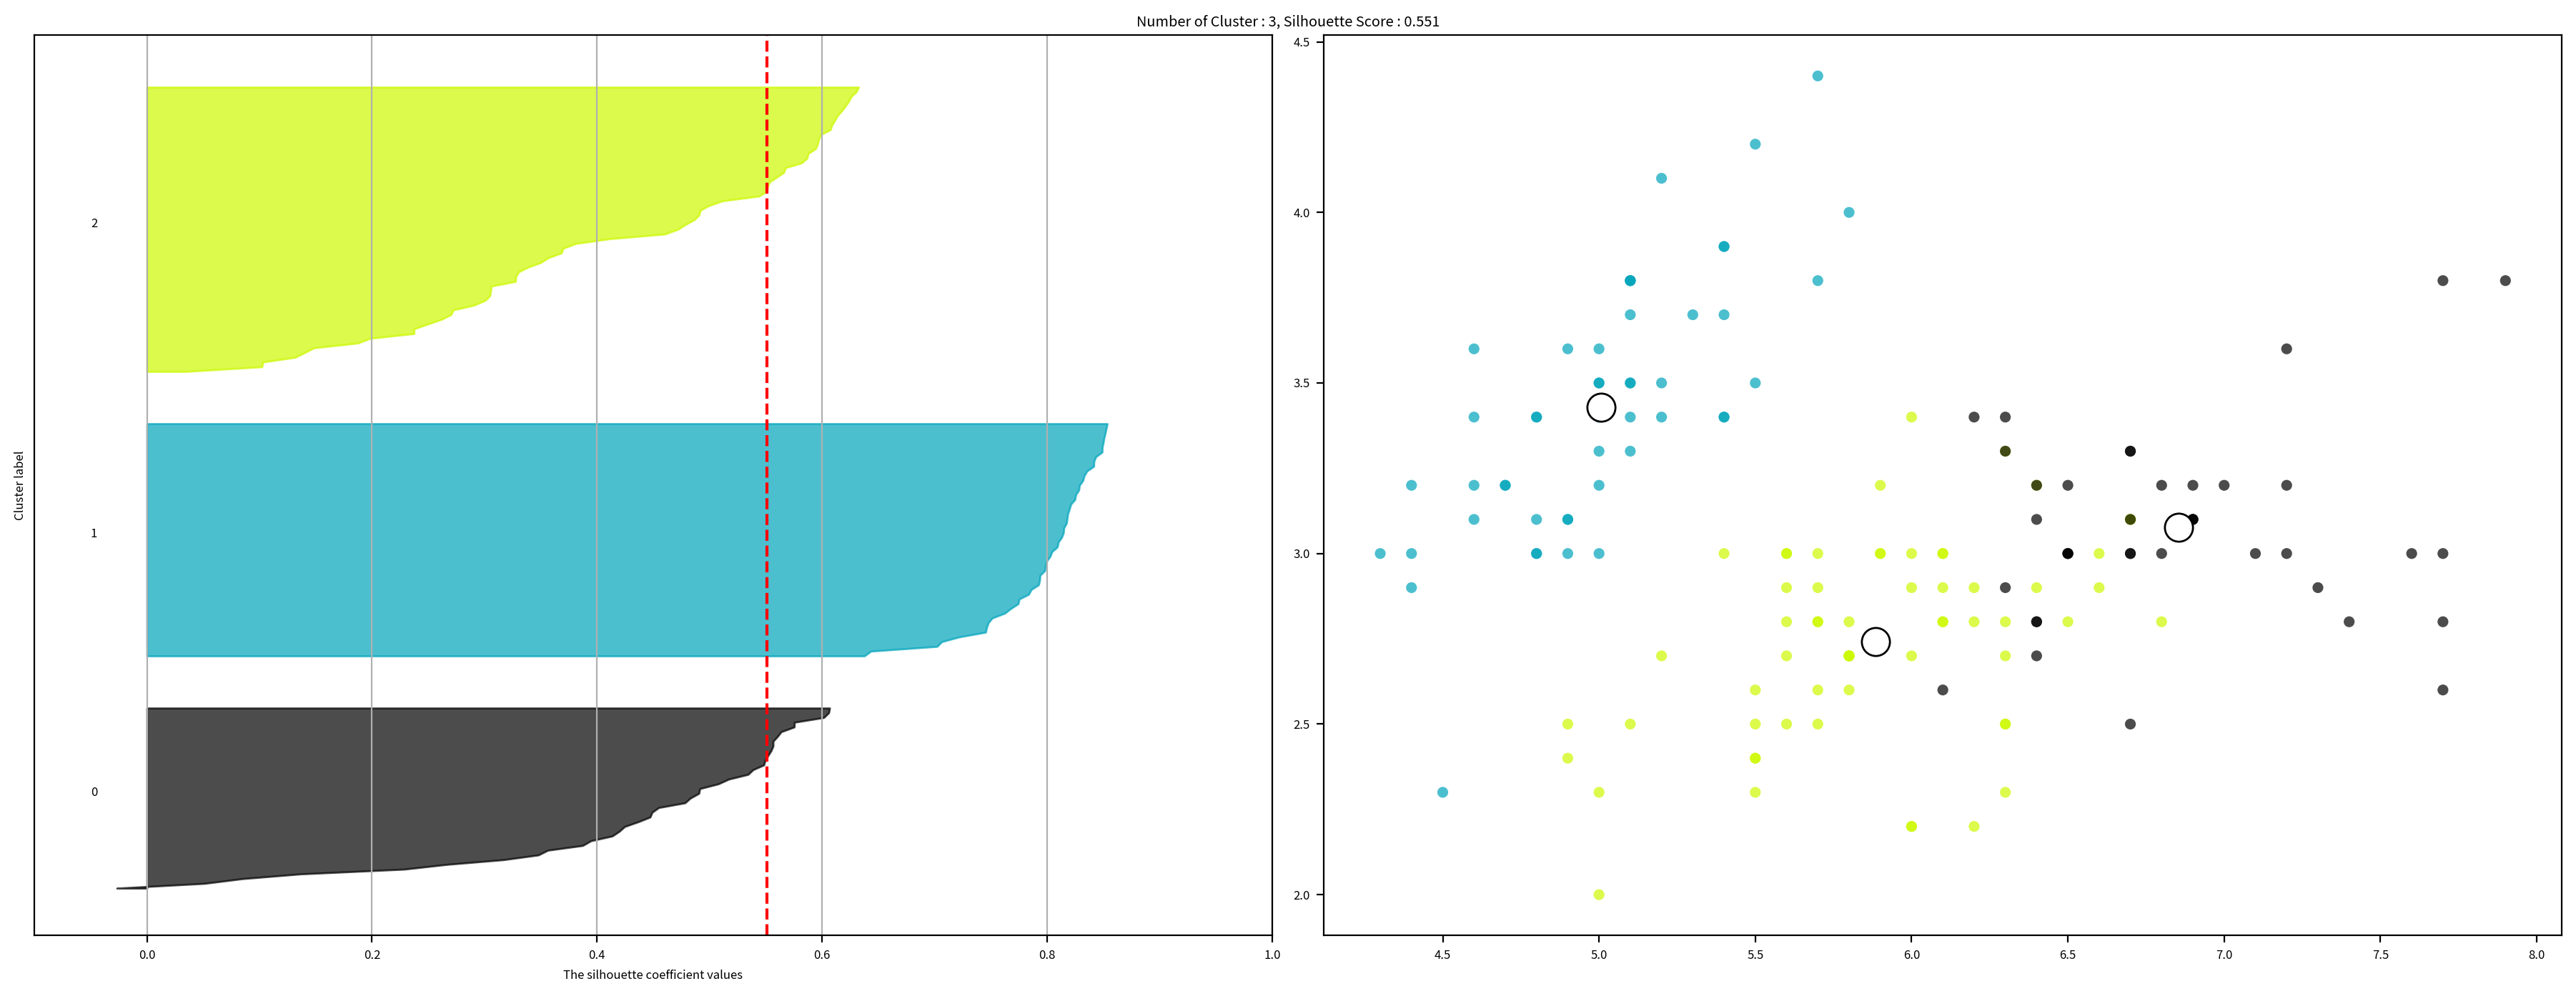

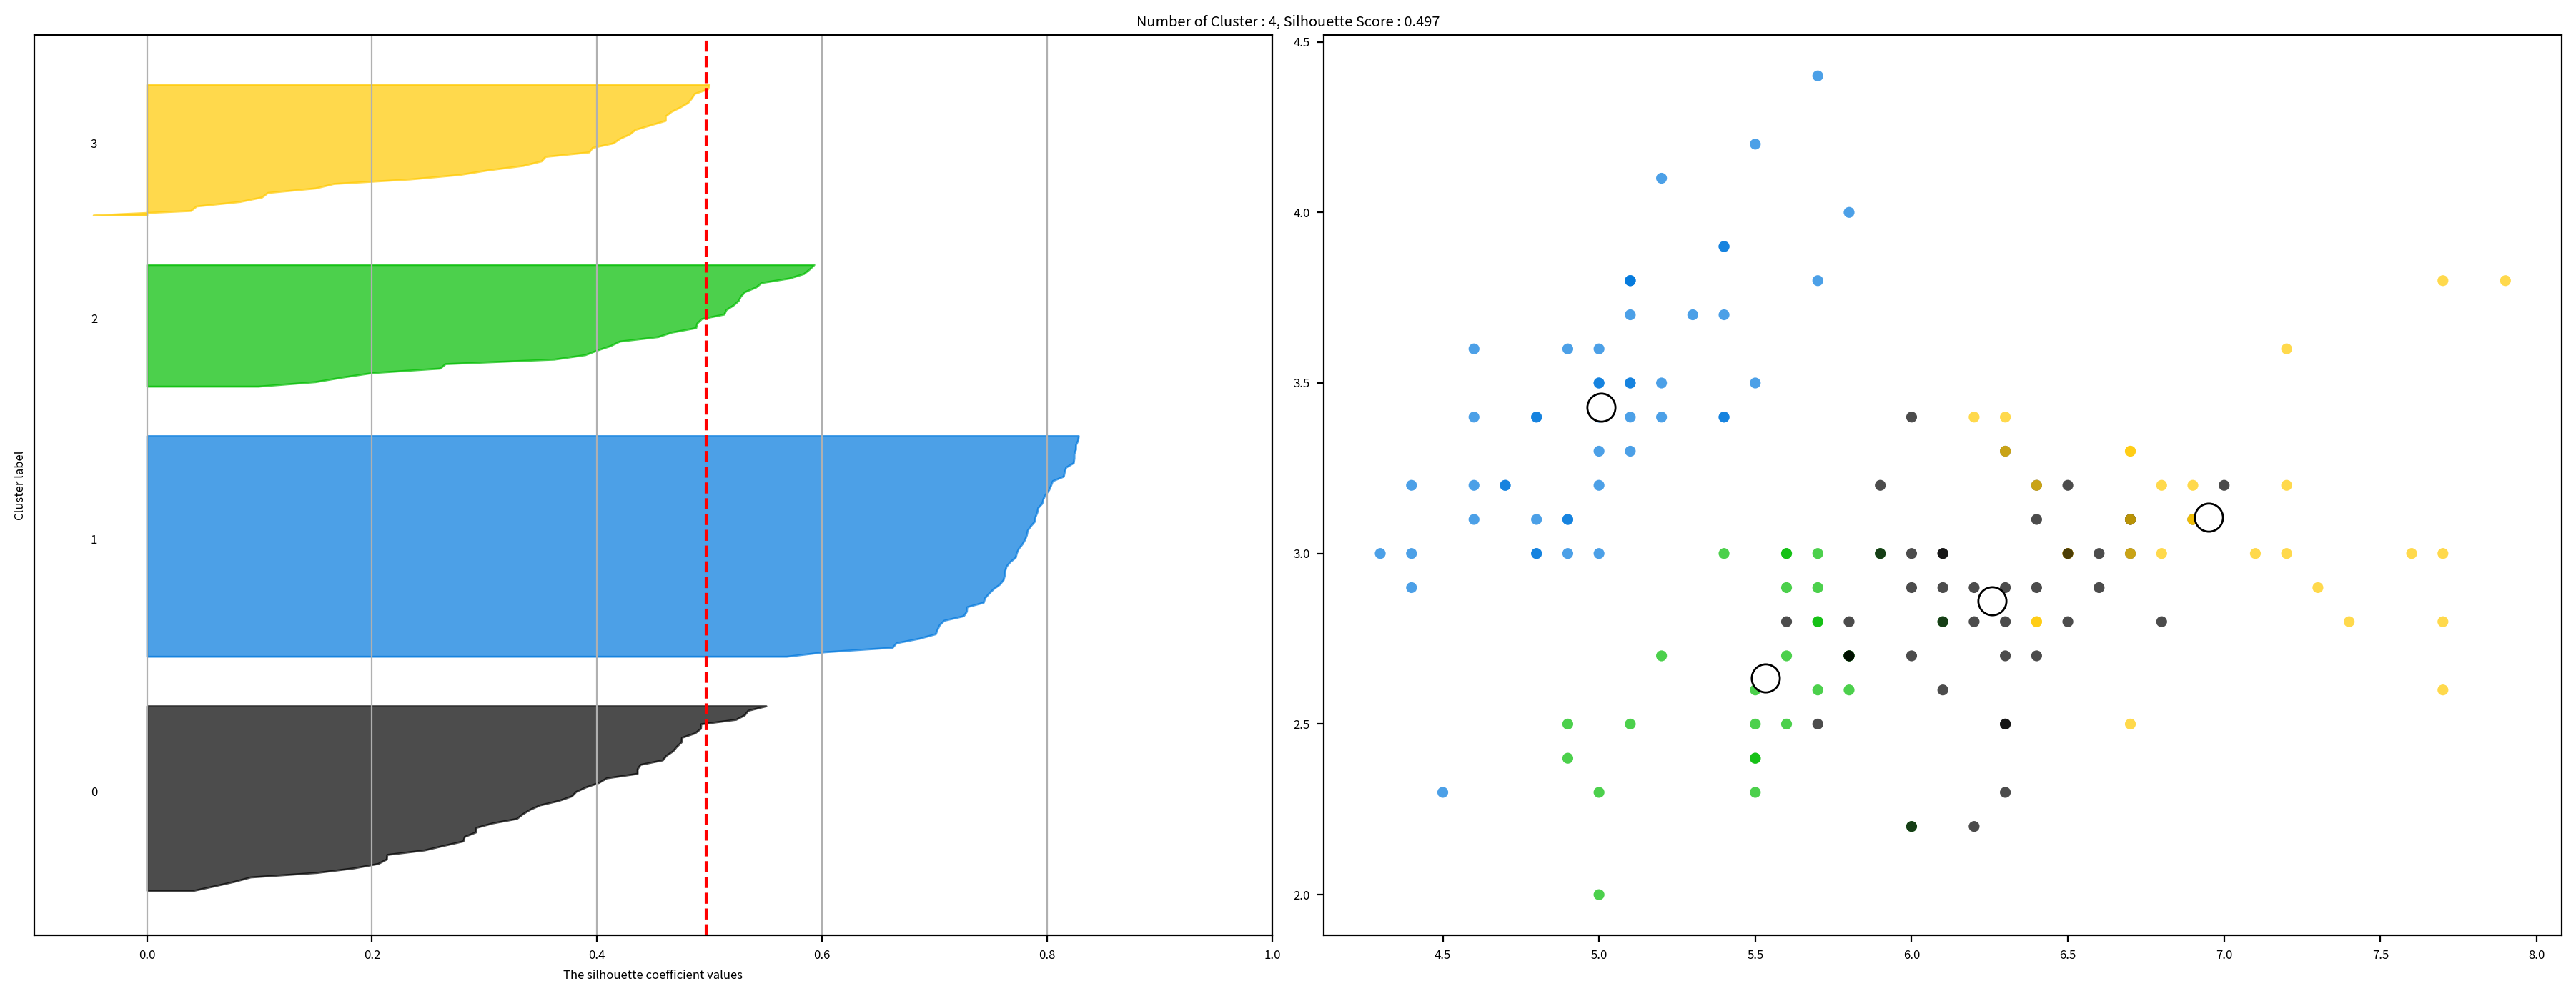

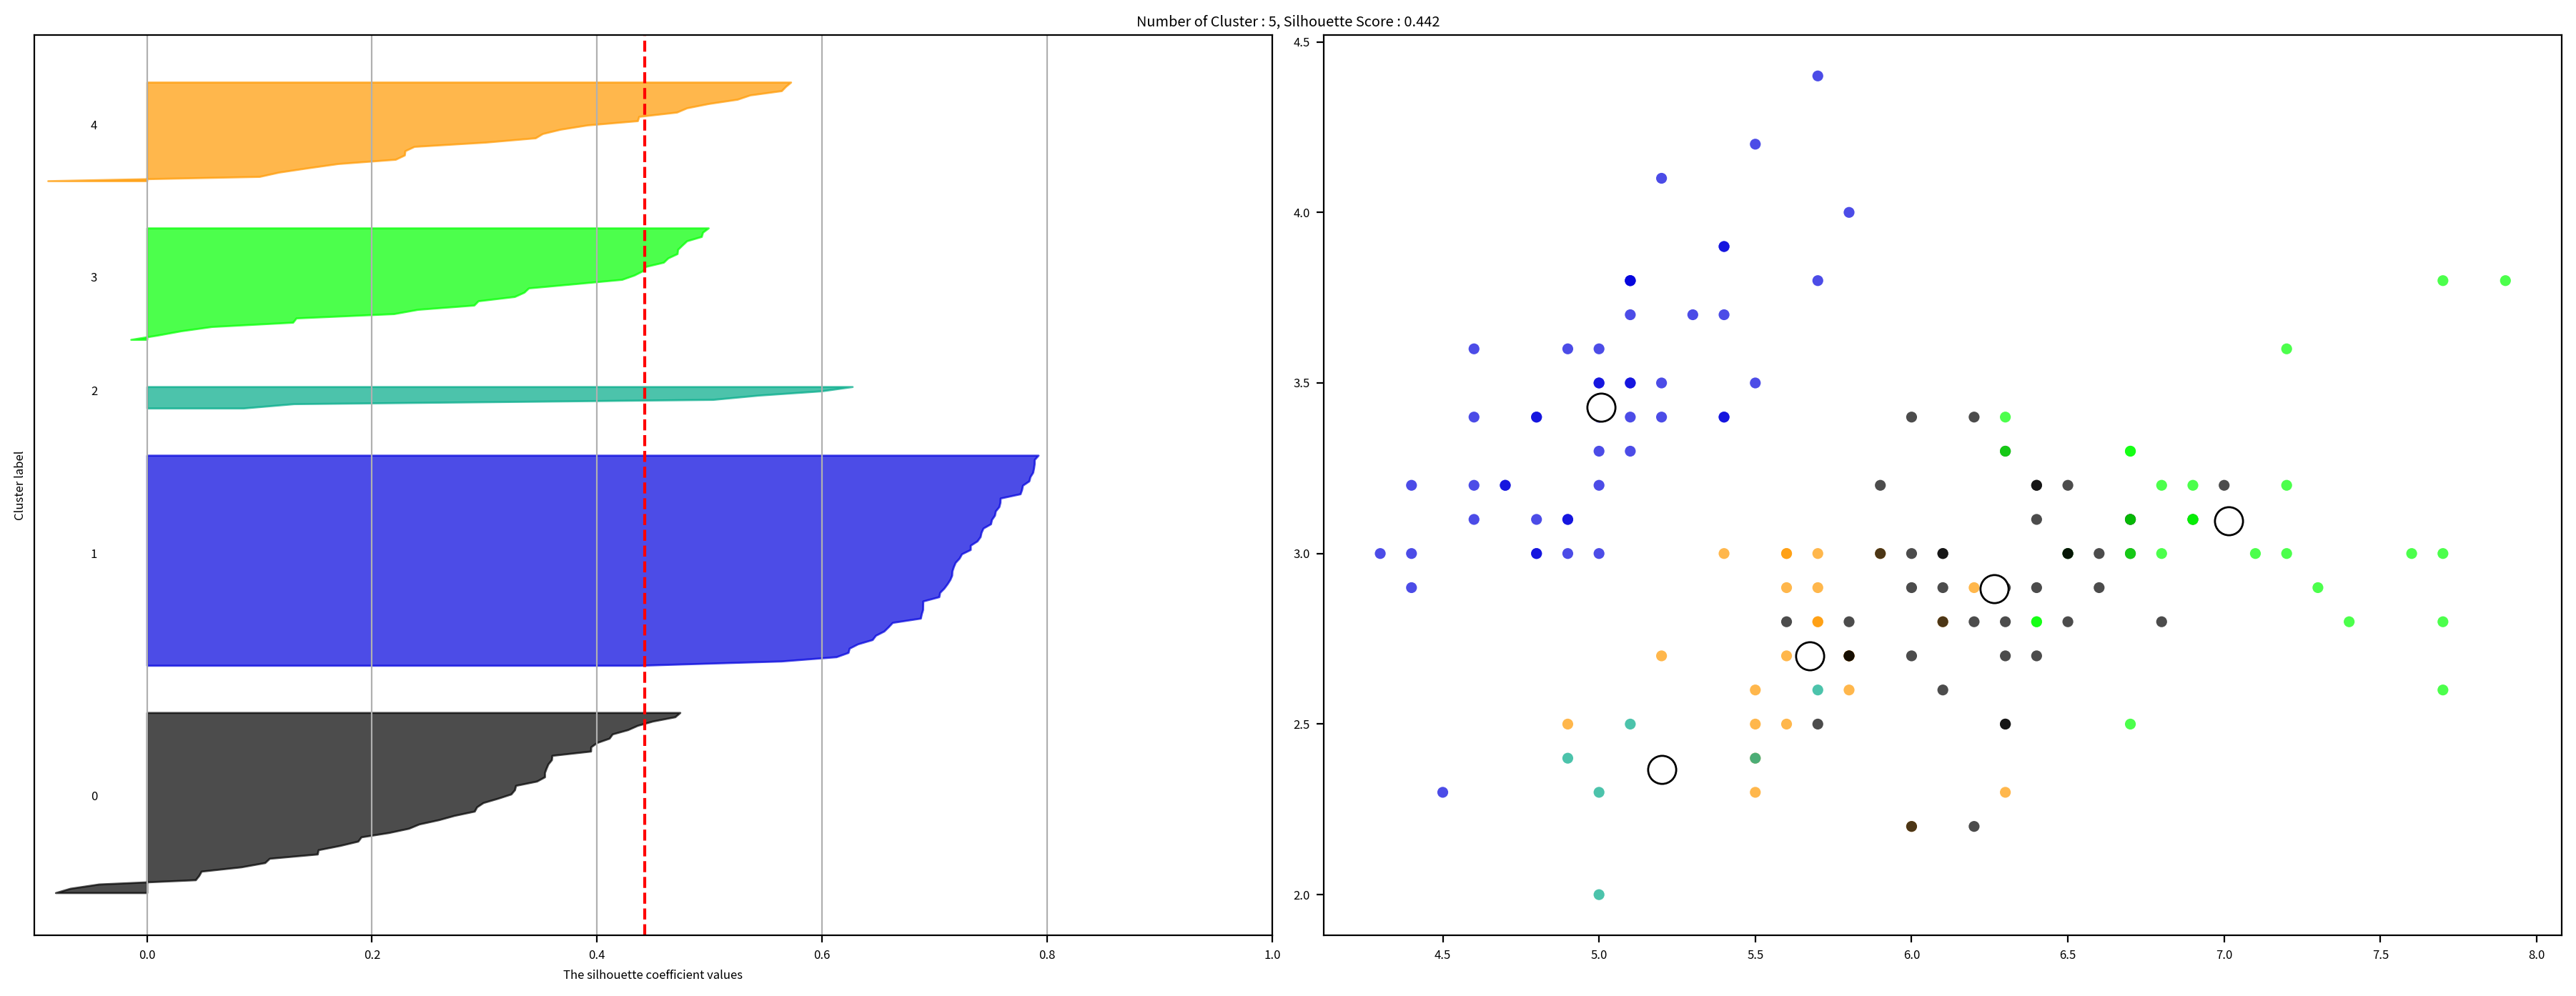

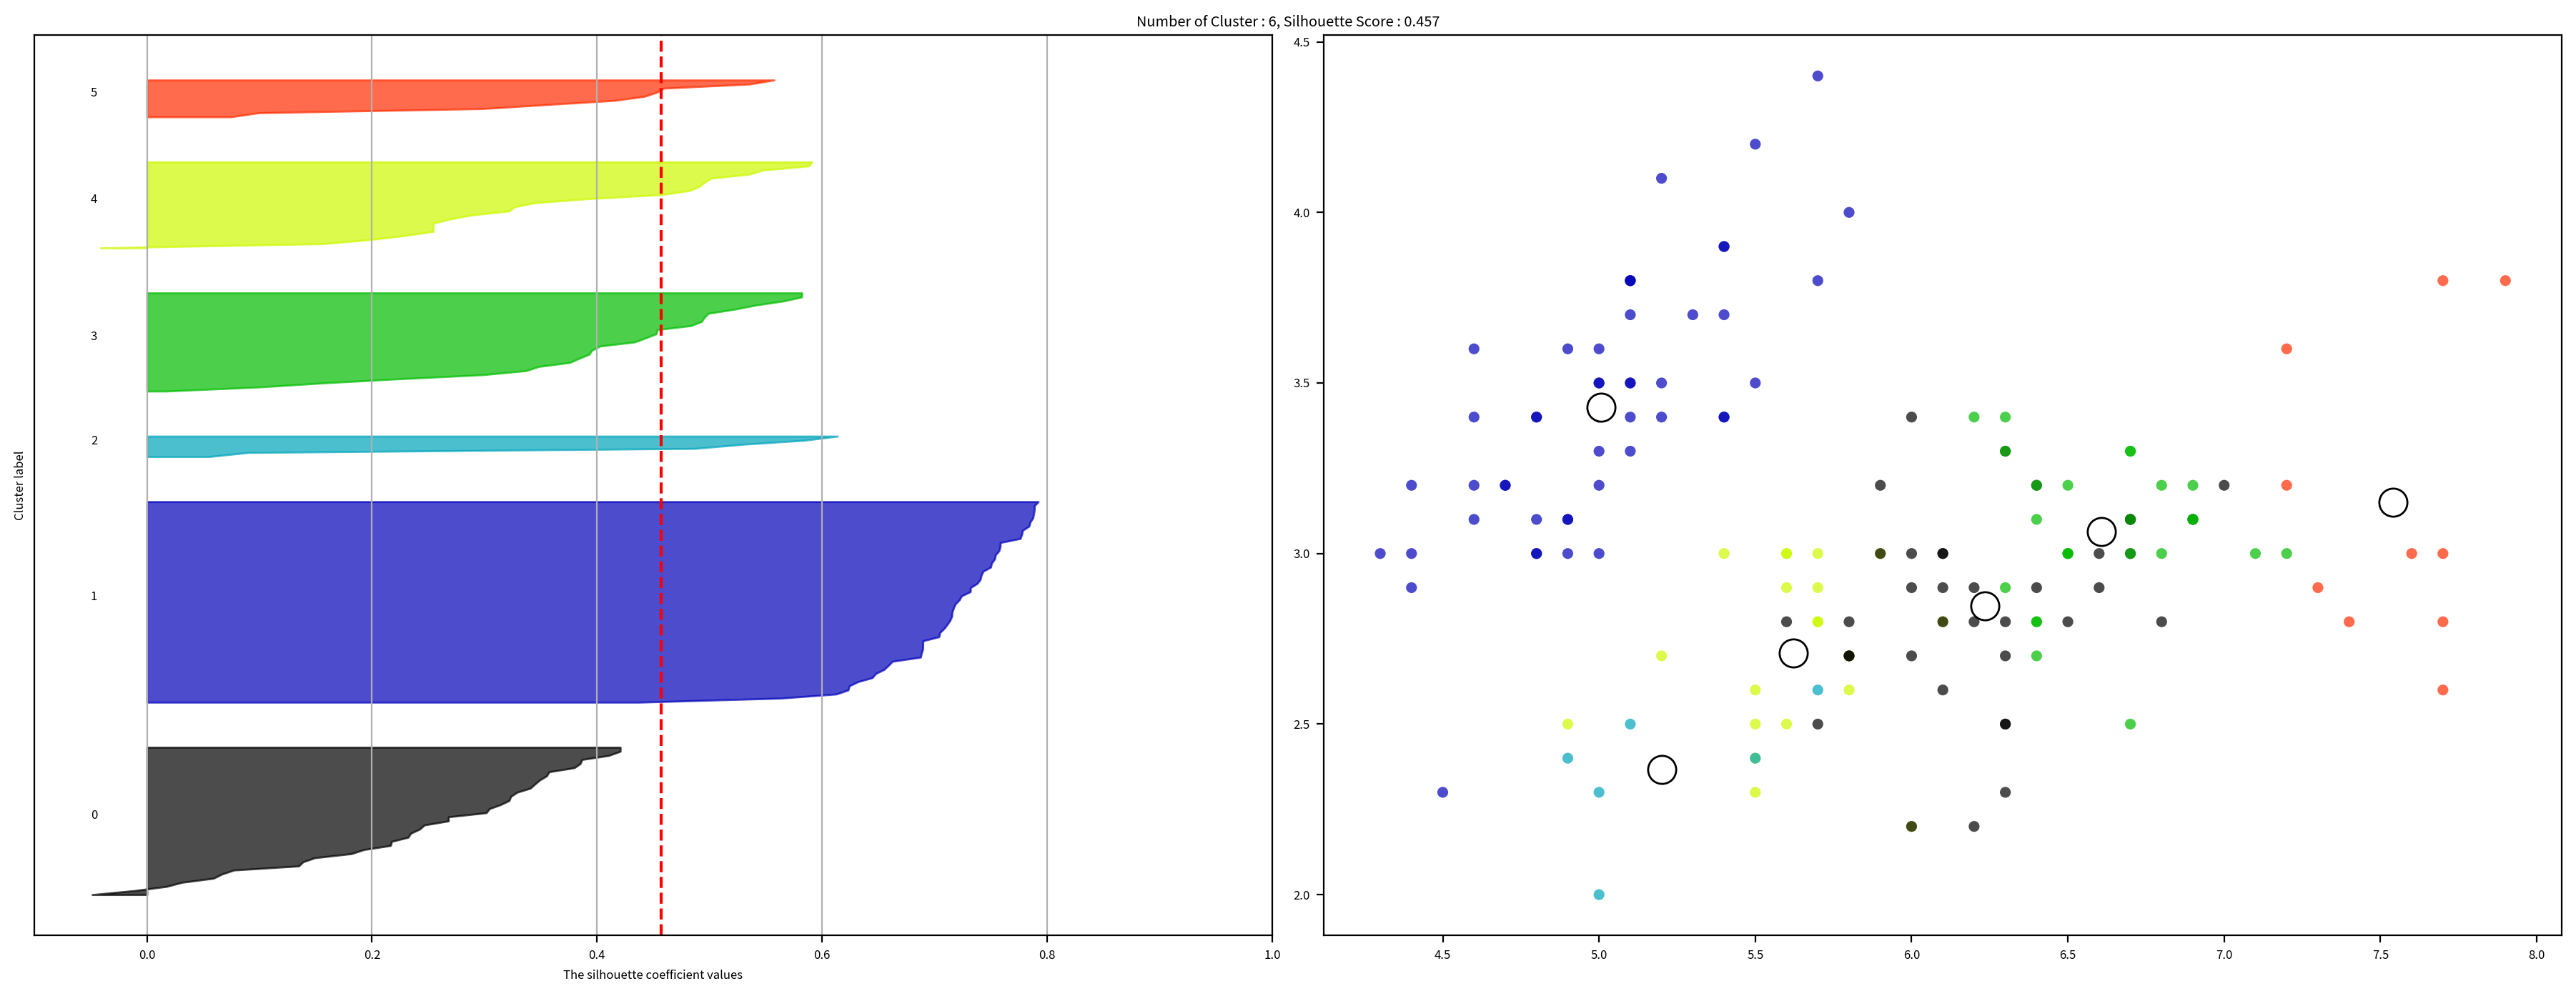

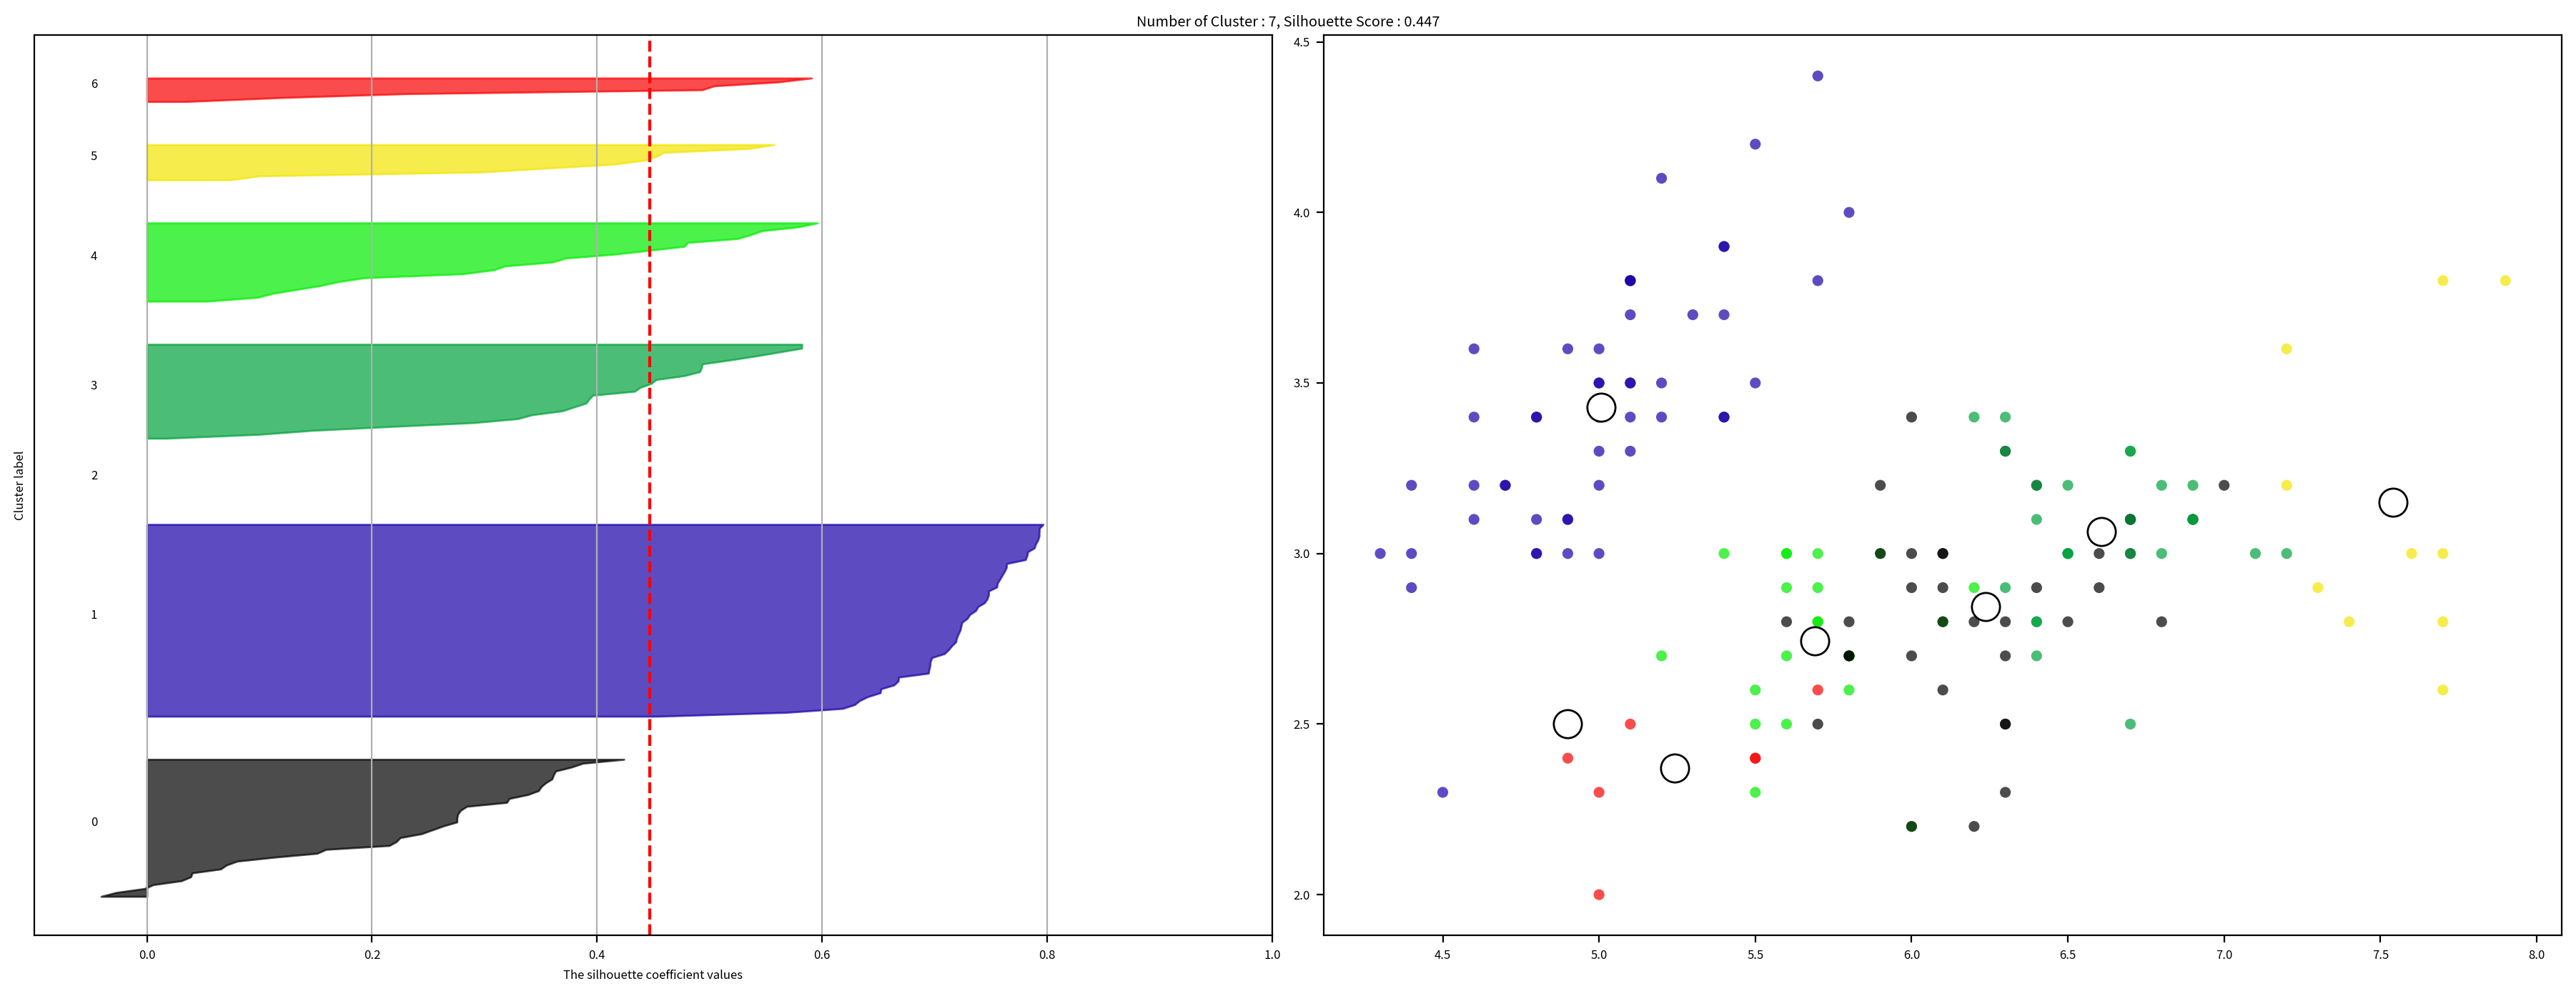

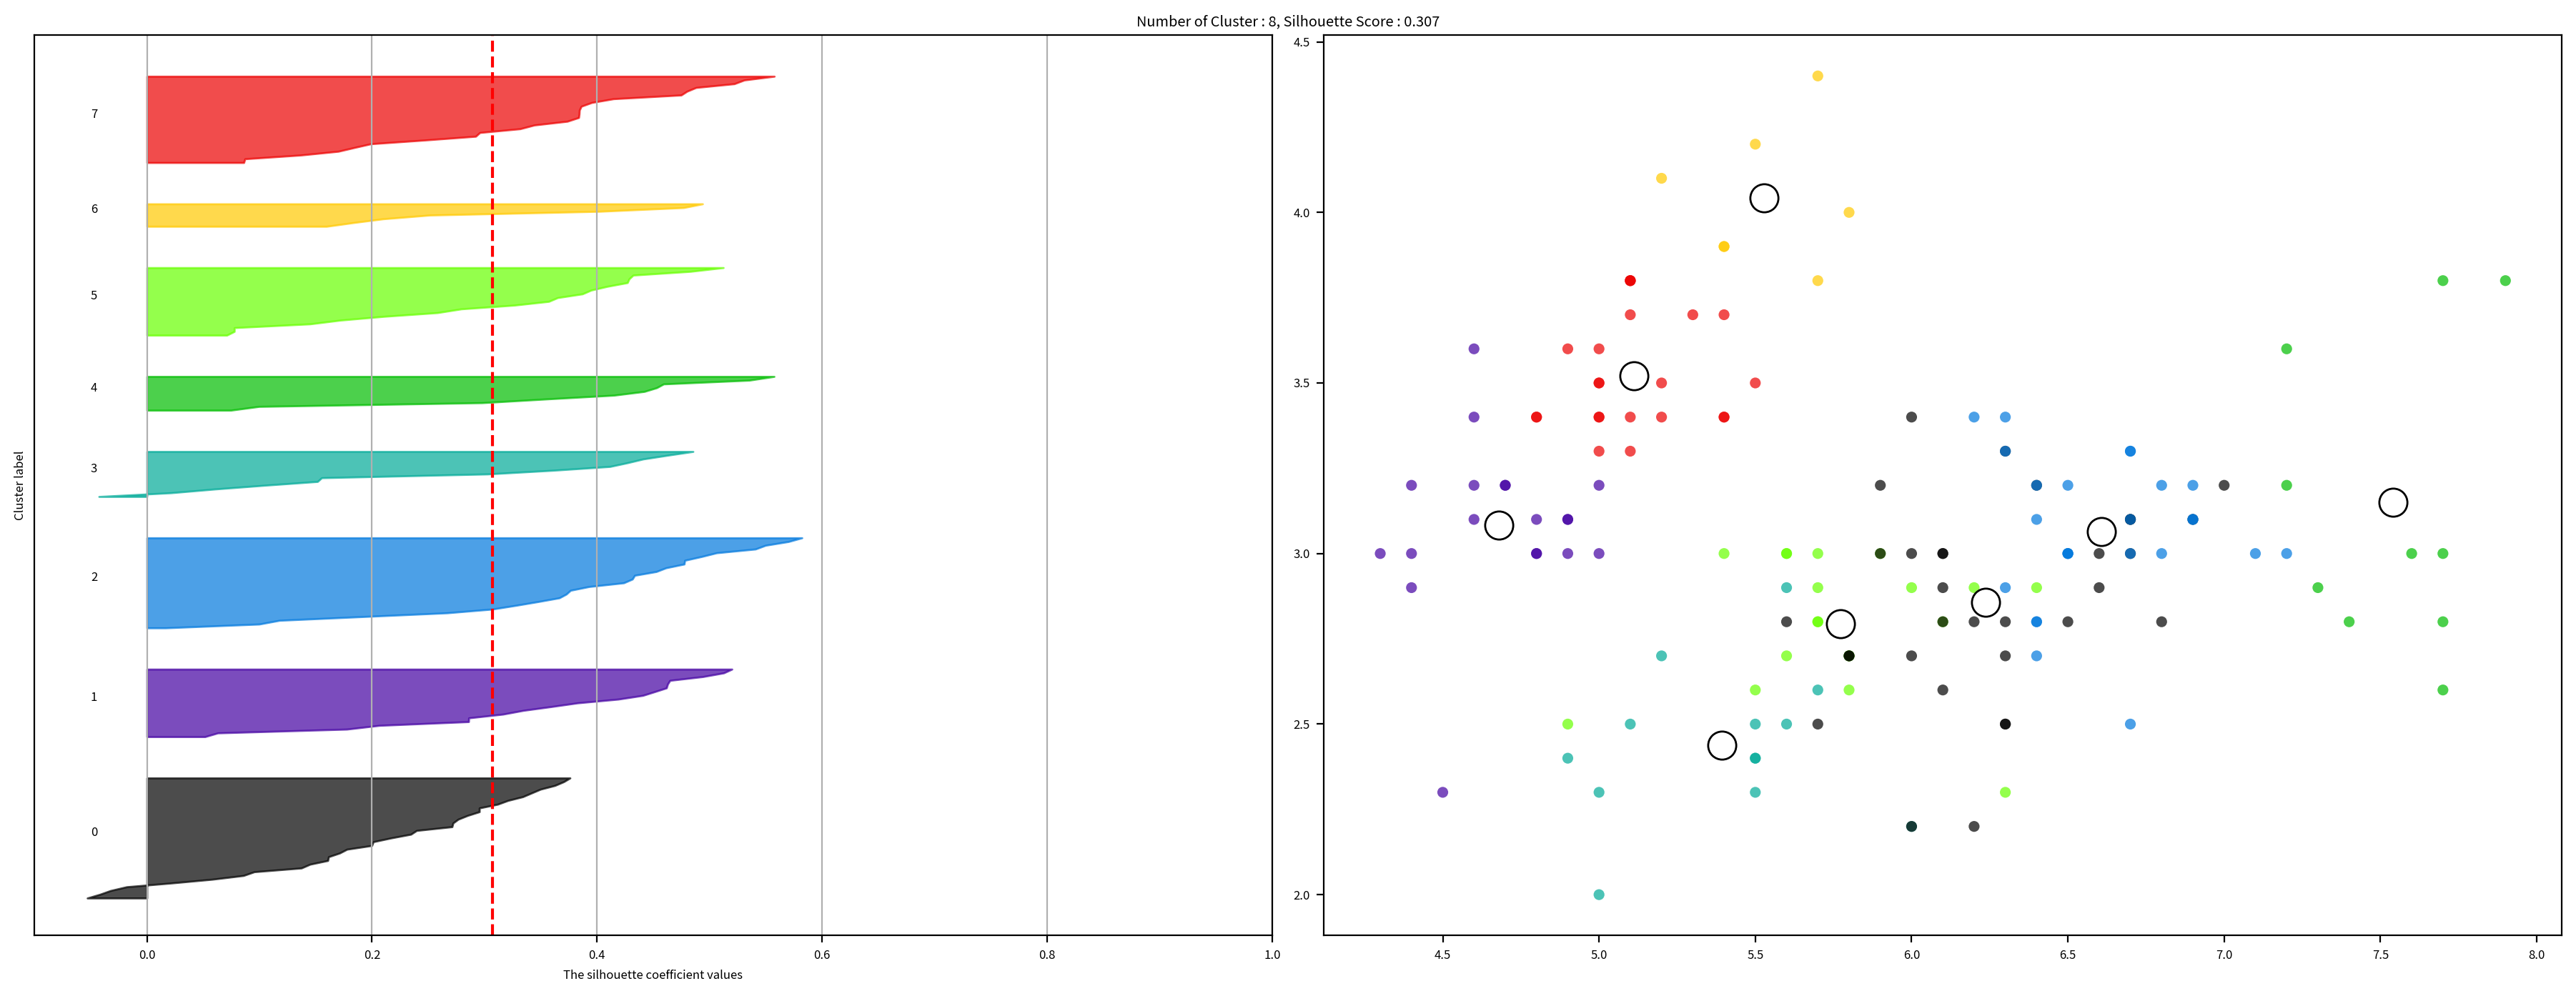

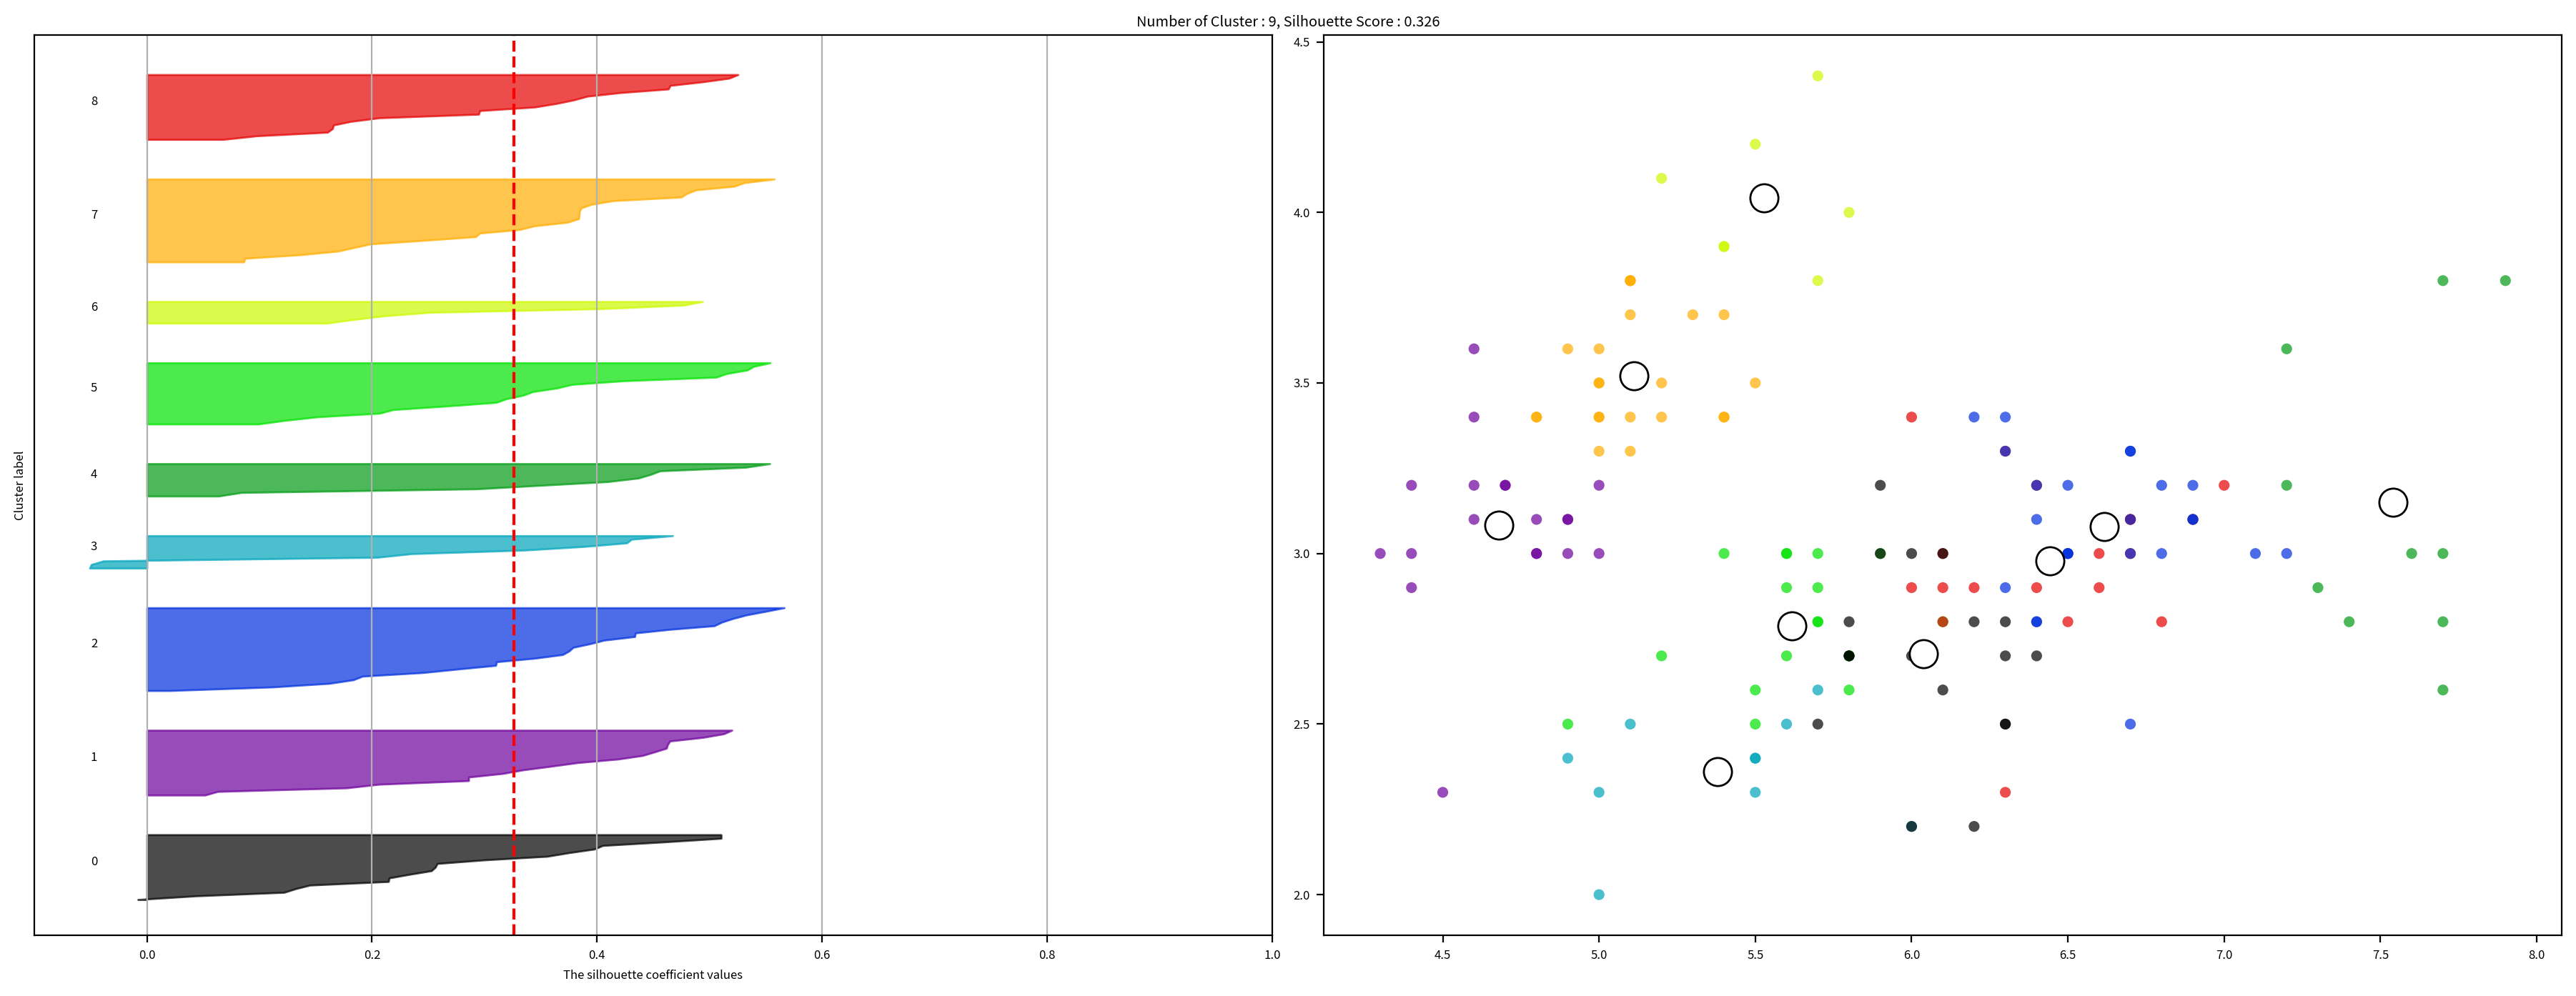

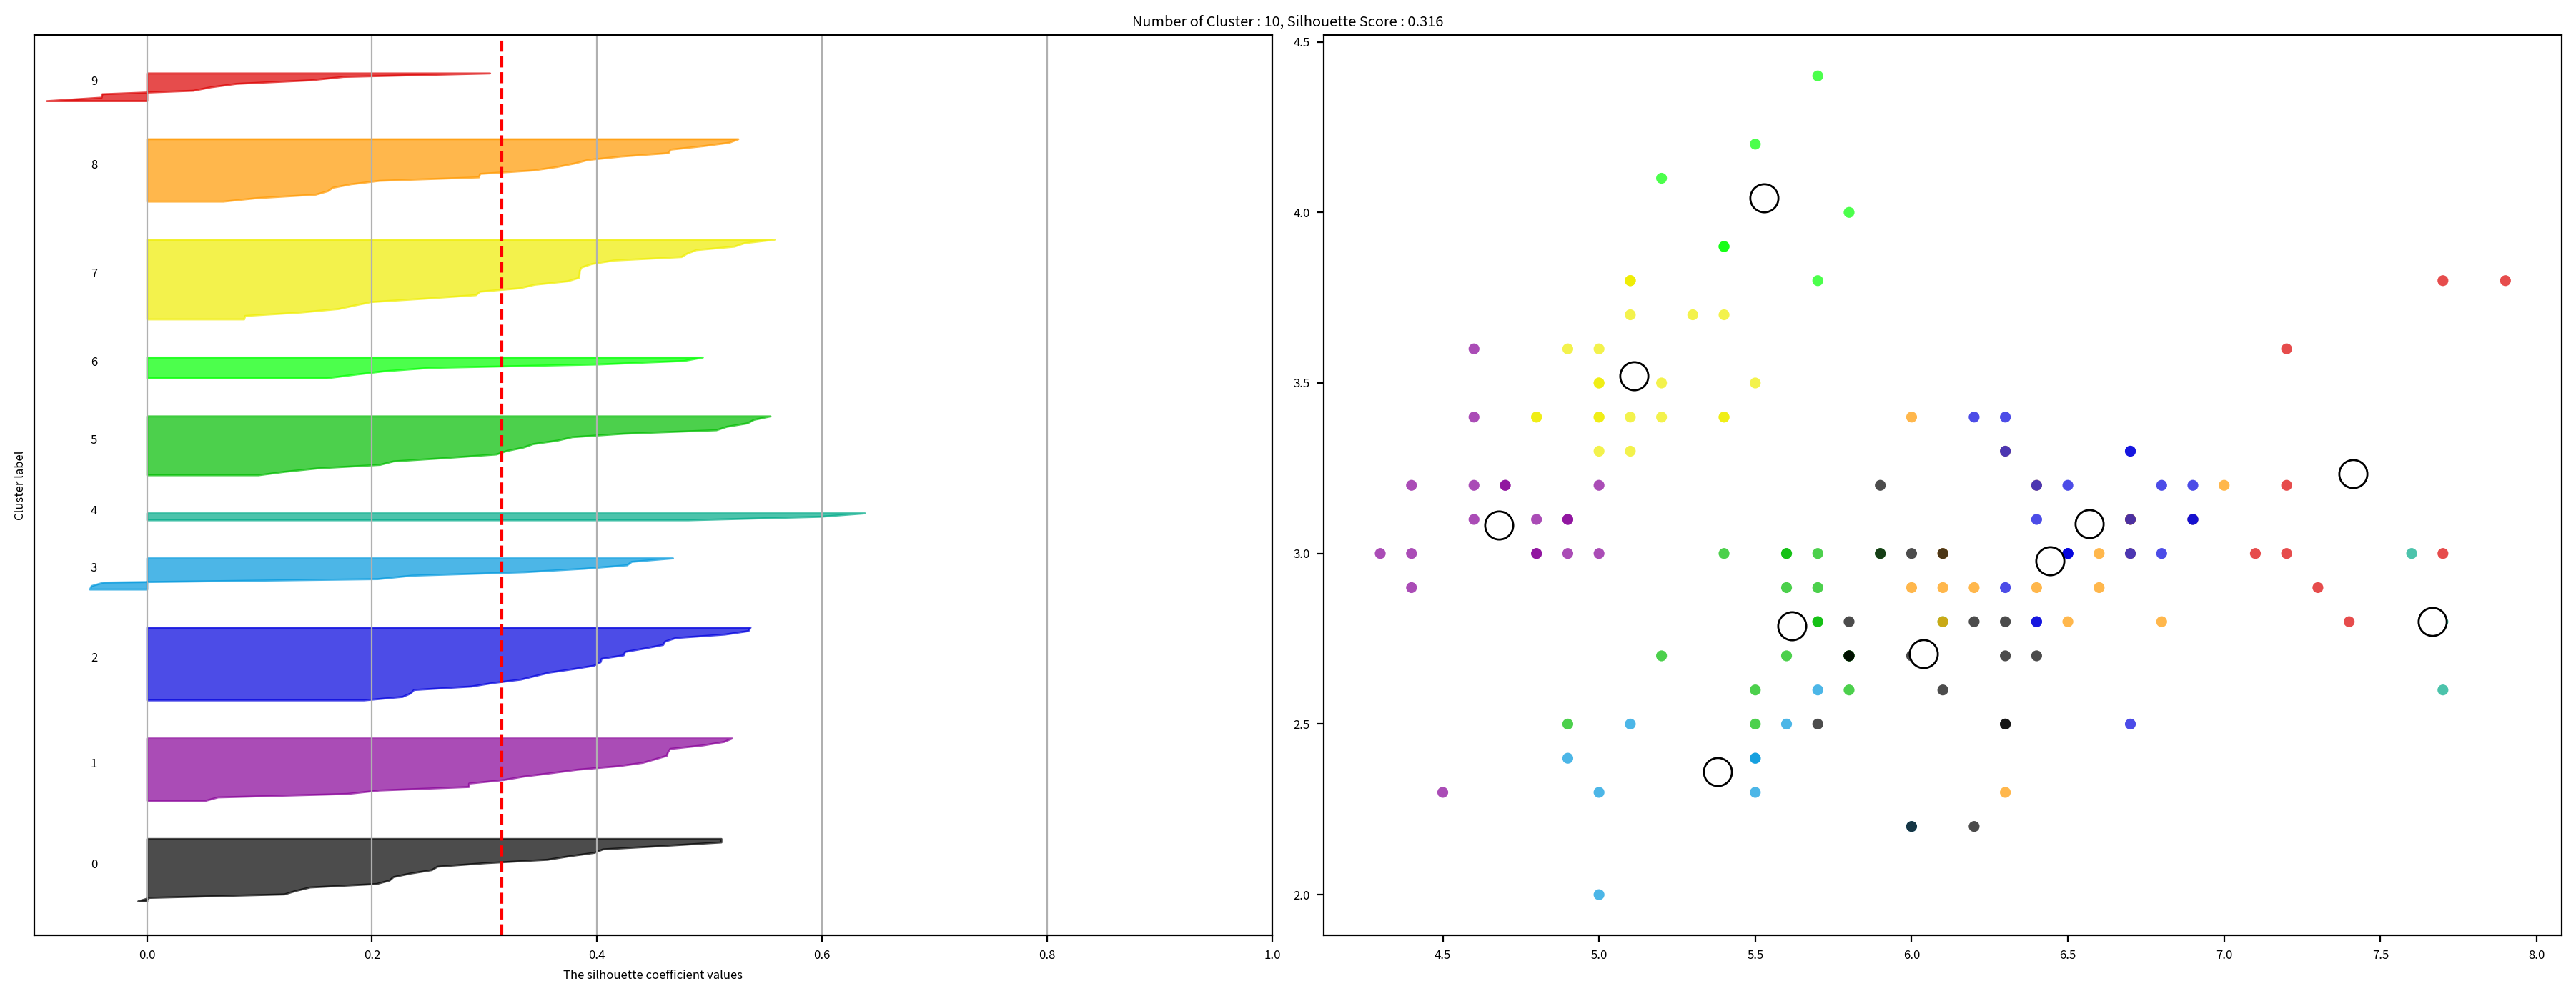

최적의 k: 3


In [55]:
# 시각화 최소 군집수 (분석 구간으로 결정)
klist = list(range(3, 11))

silhouette = []   # 실루엣 스코어 저장 리스트

for k in klist:
    estimator = KMeans(
        n_clusters=k,
        random_state=52
    )

    estimator.fit(X=df)

    cluster = estimator.predict(df)

    s_score = silhouette_score(
        X=df,
        labels=cluster
    )
    silhouette.append(s_score)

    visualize_silhouette(
        estimator=estimator,
        X_features=df
    )


# 최적 k 선택
best_k = klist[np.argmax(silhouette)]
print("최적의 k:", best_k)


## 📘#03.Kmeans의 실무 적용<br>
📝[1]다중공선성 제거<br>
📝[2]페르소나 분석

In [57]:
df

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [61]:
estimator = KMeans(n_clusters=best_k, random_state=52)
estimator.fit(X=df)
clusters = estimator.predict(df)

cdf = df.copy()
cdf["ClusterID"] = clusters
cdf.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,ClusterID
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


In [64]:
persona_list = []

for i in range(best_k):

    # 클러스터별 데이터 분리 (ClusterID 컬럼 제거)
    cluster_data = (
        cdf[cdf["ClusterID"] == i]
        .drop("ClusterID", axis=1)
    )

    persona_item = {"Cluster": i}

    for column in cluster_data.columns:

        # (이미 제거했지만 안전 차원에서 유지)
        if column == "ClusterID":
            continue

        # 정규성 검정
        stat, p = normaltest(cluster_data[column])
        alpha = 0.05

        # 정규성 여부에 따라 대표값 선택
        if p > alpha:
            persona_item[column] = cluster_data[column].mean()
        else:
            persona_item[column] = cluster_data[column].median()

    persona_list.append(persona_item)


# 결과 DataFrame 생성 및 정렬
persona_df = DataFrame(persona_list)

persona_df = (
    persona_df
    .sort_values(by="Cluster")
    .reset_index(drop=True)
)

persona_df


,Cluster,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,0,6.853846,3.076923,5.715385,2.053846
1,1,5.006000,3.428000,1.462000,0.200000
2,2,5.883607,2.740984,4.388525,1.400000


## 📘#03.군집분석 결과 활용

In [66]:
new_data = [[5.0,3.4,1.5,0.2], [6.5,3.0, 5.2, 2.0]]
new_data_df = DataFrame(new_data, columns=df.columns)
new_data_df

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,5.0,3.4,1.5,0.2
1,6.5,3.0,5.2,2.0


In [67]:
predicted_clusters = estimator.predict(new_data_df)
predicted_clusters

array([1, 0], dtype=int32)

VIF를 무조건 제거하는 건 아님<br>
단순히"VIF < 10이상인 변수들을 제거했다" 이렇게만 작성하면 안됨<br>
 - _구체적인 이유가 있어야 함_